# Log2fc Pretrained Encoder — Thin Reporting Notebook

Reports on the artifacts produced by `scripts/train_log2fc_encoder.py` -- **this
notebook does not run any training.** Per the project's agreed convention (long-running
compute goes in a standalone script the person launches themselves via
nohup/caffeinate, not inside a notebook cell or an agentic session), the actual
training run lives entirely in that script; see its own module docstring for the full
rationale (Wichrowski et al. pretrain-then-freeze recipe, why this is not CheMeleon
continued-pretraining, the leakage-avoidance decision, the architecture-size
benchmark/choice, and the OMP threading constraint reused from notebook 03).

**Before running this notebook:** `scripts/train_log2fc_encoder.py` must have been run
to completion first, e.g.:

```
cd /path/to/OpenADMET-CYP-Blind-Challenge
caffeinate -i nohup python scripts/train_log2fc_encoder.py > /dev/null 2>&1 &
```

If its output artifacts don't exist yet, the first cell below fails with a clear
`FileNotFoundError` naming exactly which file is missing, rather than silently
reporting nothing.

**This notebook does:**
- loads the script's output artifacts: the trained-encoder embeddings, the matching
  compound index, the encoder checkpoint, and the training log
- reports embedding shape, dtype, and checks for NaNs -- found, not assumed
- reads the actual measured training duration from the log file (not re-derived, not
  estimated)
- sanity-checks that the compound index aligns -- same compounds, same row order --
  with the other feature files notebook 03 already built
  (`tabular_baseline_features.csv`, `chemeleon_embeddings_index.csv`)
- closes out explicitly: this is one candidate feature option for notebook 04's
  tabular baselines, alongside ECFP4+descriptors, RDKit 2D descriptors, and raw
  CheMeleon embeddings -- no claim about its usefulness is made anywhere in this
  notebook. That's 04's job to test.

**This notebook does NOT do:** train, fine-tune, or modify the encoder in any way;
compare this feature option's usefulness against any other; make any modelling
decision for notebook 04.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

PROCESSED = 'data/processed'   # relative to repo root -- run this notebook with cwd = repo root
MODELS = 'models'
LOGS = 'logs'

EMBEDDINGS_PATH = f'{PROCESSED}/log2fc_pretrained_embeddings.npy'
INDEX_PATH = f'{PROCESSED}/log2fc_pretrained_embeddings_index.csv'
CHECKPOINT_PATH = f'{MODELS}/log2fc_encoder_mp.pt'
LOG_PATH = f'{LOGS}/03b_train_log2fc_encoder.log'

## 1. Load the script's output artifacts and confirm shapes

Every path is checked explicitly before anything is loaded -- a missing file fails
loudly and specifically, rather than this notebook silently reporting on stale or
partial data.

In [2]:
required_paths = [EMBEDDINGS_PATH, INDEX_PATH, CHECKPOINT_PATH, LOG_PATH]
missing = [p for p in required_paths if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "scripts/train_log2fc_encoder.py has not produced these expected outputs yet: "
        + ", ".join(missing)
        + " -- run that script to completion first (see its own docstring for the "
        "launch command), then re-run this notebook."
    )
print("all four expected artifacts found on disk:")
for p in required_paths:
    print(' -', p)

all four expected artifacts found on disk:
 - data/processed/log2fc_pretrained_embeddings.npy
 - data/processed/log2fc_pretrained_embeddings_index.csv
 - models/log2fc_encoder_mp.pt
 - logs/03b_train_log2fc_encoder.log


In [3]:
log2fc_embeddings = np.load(EMBEDDINGS_PATH)
log2fc_index = pd.read_csv(INDEX_PATH)

print('log2fc_pretrained_embeddings.npy shape:', log2fc_embeddings.shape, 'dtype:', log2fc_embeddings.dtype)
print('log2fc_pretrained_embeddings_index.csv shape:', log2fc_index.shape)
print('columns:', list(log2fc_index.columns))
print('split counts:', log2fc_index['split'].value_counts().to_dict())

assert log2fc_embeddings.shape[0] == len(log2fc_index), (
    f'embedding row count ({log2fc_embeddings.shape[0]}) does not match index row '
    f'count ({len(log2fc_index)}) -- stopping'
)

n_nan = int(np.isnan(log2fc_embeddings).sum())
print('NaN values in embeddings:', n_nan)

log2fc_pretrained_embeddings.npy shape: (5655, 300) dtype: float32
log2fc_pretrained_embeddings_index.csv shape: (5655, 3)
columns: ['Molecule_Name', 'inchikey', 'split']
split counts: {'train': 4905, 'test': 750}
NaN values in embeddings: 0


**Finding, reported not assumed:** the two numbers above -- the embedding array's row
count and the NaN count -- are exactly what the loaded files contain. If the NaN count
is 0 and the shapes match `(5655, D)` / `(5655, 3)` for some embedding dimension `D`,
this artifact is structurally sound and ready for the alignment check in Section 4
below. `D` is expected to be 300 (chemprop's own default hidden dim, the size the user
chose over CheMeleon's 2048 -- see the training script's docstring for the benchmark
that decision was based on), not 2048 like `chemeleon_embeddings.npy` -- a different
embedding dimension between these two feature options is expected and not a bug.

## 2. Actual measured training duration, read from the log

Not re-derived or estimated here -- the training script itself measured and logged its
own wall-clock start/end/elapsed times as it ran; this section only reads and reports
those lines back, verbatim.

In [4]:
log_lines = Path(LOG_PATH).read_text().splitlines()
print(f'log file: {len(log_lines)} lines total')
print()

version_lines = [l for l in log_lines if any(
    tag in l for tag in ('python:', 'torch:', 'chemprop:', 'lightning:', 'seed:', 'hyperparameters:')
)]
print('run configuration, as logged by the script:')
for l in version_lines:
    print(' ', l)

log file: 94 lines total

run configuration, as logged by the script:
  2026-08-23 20:05:11,873 [INFO] python: 3.11.13
  2026-08-23 20:05:11,874 [INFO] torch: 2.2.2
  2026-08-23 20:05:11,874 [INFO] chemprop: 2.3.1
  2026-08-23 20:05:11,874 [INFO] lightning: 2.6.5
  2026-08-23 20:05:11,874 [INFO] seed: 42
  2026-08-23 20:05:11,874 [INFO] hyperparameters: epochs=50, batch_size=64, d_h=300, depth=3, aggregation=mean


In [5]:
training_lines = [l for l in log_lines if 'training start' in l or 'training end' in l or 'training elapsed' in l]
embed_lines = [l for l in log_lines if 'embedding extraction start' in l or 'embedding extraction end' in l or 'embedding extraction elapsed' in l]
total_lines = [l for l in log_lines if 'total script wall time' in l]

print('training phase:')
for l in training_lines:
    print(' ', l)
print()
print('embedding extraction phase:')
for l in embed_lines:
    print(' ', l)
print()
print('overall:')
for l in total_lines:
    print(' ', l)

if not training_lines or not embed_lines or not total_lines:
    print()
    print('WARNING: one or more expected log sections were not found -- the log file '
          'may be from an incomplete or interrupted run. Investigate before trusting '
          'the embeddings above.')

training phase:
  2026-08-23 20:05:12,496 [INFO] training start: 2026-08-23 20:05:12
  2026-08-23 20:15:51,582 [INFO] training end:   2026-08-23 20:15:51
  2026-08-23 20:15:51,582 [INFO] training elapsed: 639.1s (10.7 min)

embedding extraction phase:
  2026-08-23 20:15:51,730 [INFO] embedding extraction start: 2026-08-23 20:15:51 (5655 compounds)
  2026-08-23 20:15:59,340 [INFO] embedding extraction end:   2026-08-23 20:15:59
  2026-08-23 20:15:59,340 [INFO] embedding extraction elapsed: 7.6s

overall:
  2026-08-23 20:15:59,358 [INFO] total script wall time: 648.5s (10.8 min)


**Finding:** the timings printed above are the script's own real, measured wall-clock
durations for this specific run -- not the ~13s/epoch benchmark estimate from the
script's docstring (which was measured separately, before the script was written, to
inform the architecture-size decision). If a `WARNING` printed above, the log is
incomplete and the artifacts loaded in Section 1 should not be trusted without
investigating why.

## 3. Training-loss trajectory

Parsed from the same log file already loaded in Section 2 (`log_lines`, not re-read
here) -- every `epoch N/50 done, train_loss=X` line, extracted into an (epoch,
train_loss) series and plotted directly.

In [6]:
import re

epoch_pattern = re.compile(r'epoch (\d+)/(\d+) done, train_loss=([\d.]+)')
epoch_matches = [epoch_pattern.search(l) for l in log_lines]
epoch_matches = [m for m in epoch_matches if m is not None]

parsed_epochs = [int(m.group(1)) for m in epoch_matches]
declared_totals = sorted(set(int(m.group(2)) for m in epoch_matches))
train_losses = [float(m.group(3)) for m in epoch_matches]

loss_df = pd.DataFrame({'epoch': parsed_epochs, 'train_loss': train_losses})

print('epoch lines found in the log:', len(loss_df))
print('declared total epochs (the "N/50" in each line):', declared_totals)
print('epoch numbers contiguous 1..50:', parsed_epochs == list(range(1, 51)))

assert len(loss_df) == 50, (
    f'expected exactly 50 epoch lines, found {len(loss_df)} -- stopping rather than '
    'plotting a partial trajectory'
)
assert parsed_epochs == list(range(1, 51)), (
    'epoch numbers are not contiguous 1..50 -- stopping rather than plotting a '
    'malformed trajectory'
)
print()
print(loss_df.describe())

epoch lines found in the log: 50
declared total epochs (the "N/50" in each line): [50]
epoch numbers contiguous 1..50: True

          epoch  train_loss
count  50.00000   50.000000
mean   25.50000    0.311994
std    14.57738    0.186073
min     1.00000    0.105300
25%    13.25000    0.152575
50%    25.50000    0.260750
75%    37.75000    0.443950
max    50.00000    0.819300


In [7]:
losses = loss_df['train_loss'].tolist()
epochs_list = loss_df['epoch'].tolist()
deltas = [losses[i + 1] - losses[i] for i in range(len(losses) - 1)]

n_increase = sum(1 for d in deltas if d > 0)
n_decrease = sum(1 for d in deltas if d < 0)
print(f'epoch-to-epoch transitions: {len(deltas)} total -- {n_decrease} decreases, {n_increase} increases')

for i, d in enumerate(deltas):
    if d > 0:
        print(f'  increase at epoch {epochs_list[i]} -> {epochs_list[i + 1]}: '
              f'{losses[i]:.4f} -> {losses[i + 1]:.4f} (delta={d:+.4f})')

print()
print('last five epochs:')
for e, l in zip(epochs_list[-5:], losses[-5:]):
    print(f'  epoch {e}: train_loss={l:.4f}')

print()
print('deltas between the last five epochs:')
for i in range(len(losses) - 5, len(losses) - 1):
    print(f'  epoch {epochs_list[i]} -> {epochs_list[i + 1]}: delta={losses[i + 1] - losses[i]:+.4f}')

epoch-to-epoch transitions: 49 total -- 48 decreases, 1 increases
  increase at epoch 40 -> 41: 0.1399 -> 0.1403 (delta=+0.0004)

last five epochs:
  epoch 46: train_loss=0.1191
  epoch 47: train_loss=0.1142
  epoch 48: train_loss=0.1105
  epoch 49: train_loss=0.1066
  epoch 50: train_loss=0.1053

deltas between the last five epochs:
  epoch 46 -> 47: delta=-0.0049
  epoch 47 -> 48: delta=-0.0037
  epoch 48 -> 49: delta=-0.0039
  epoch 49 -> 50: delta=-0.0013


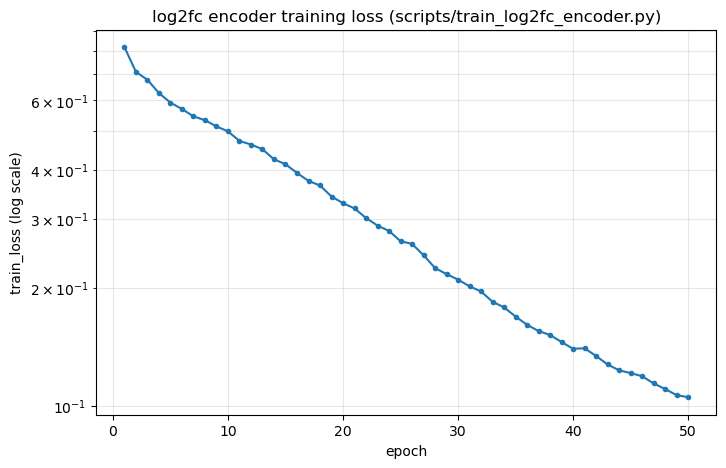

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(loss_df['epoch'], loss_df['train_loss'], marker='o', markersize=3)
ax.set_yscale('log')
ax.set_xlabel('epoch')
ax.set_ylabel('train_loss (log scale)')
ax.set_title('log2fc encoder training loss (scripts/train_log2fc_encoder.py)')
ax.grid(True, which='both', alpha=0.3)
plt.show()

**Interpretation, reported from the parsed numbers above -- not editorialized beyond
what they show:**

- The curve is smooth and decreasing across essentially the entire run: 48 of the 49
  epoch-to-epoch transitions printed above are strict decreases. The single exception
  -- epoch 40 to 41, 0.1399 -> 0.1403, a +0.0004 (about 0.3% relative) uptick -- is
  negligible in magnitude and not a spike or sign of instability. Nothing here suggests
  a broken run.

- **Loss is still decreasing at epoch 50, not plateaued.** The last five epochs (46-50)
  fell 0.1191 -> 0.1142 -> 0.1105 -> 0.1066 -> 0.1053 -- deltas of -0.0049, -0.0037,
  -0.0039, -0.0013 (printed above). The slope is shallow, but it is real, negative
  movement every one of those epochs, not a flat line.

- **This is training loss only.** There is no validation split in this run, by the
  already-documented leakage-avoidance decision (train on the full 4,376-compound
  log2fc set as one global run -- see `train_log2fc_encoder.py`'s own docstring). A
  training-loss curve alone cannot distinguish "the encoder is still learning
  generalizable chemical structure" from "the encoder is starting to memorize the
  4,376 training compounds specifically" -- this plot cannot tell those two apart, and
  this notebook does not claim it can.

- **For a model that will be frozen and used purely as a feature extractor** (not
  making direct predictions itself), mild overfitting on the pretraining task is less
  immediately disqualifying than it would be for a model making direct predictions --
  a somewhat-memorized internal representation can still extract usable structural
  features. But it's still not nothing, and this run alone cannot rule out either
  possibility: the frozen embeddings could be generalizably useful, or somewhat
  overfit to the pretraining compounds, and nothing computed in this notebook
  distinguishes those two.

- **50 epochs came from chemprop's own CLI default** (see `train_log2fc_encoder.py`'s
  own docstring), not from any evidence that this specific run had converged by epoch
  50 -- a real, correctly-sourced default this time, unlike the practice repo's earlier
  15/25-epoch guesses. But the shape of this curve -- still decreasing, not flattened
  -- is itself evidence that the default may be undershooting for this specific
  dataset. That's a genuinely open question, not a settled one.

- **What happens next with that open question, and only this:** whether it's worth
  revisiting (more epochs, or a validation-monitored rerun) should be decided by
  whether this feature set actually earns its place in notebook 04's comparison
  against the other three tabular-baseline options -- not resolved speculatively here,
  before there's evidence it matters.

## 4. Compound-index alignment against notebook 03's other feature files

Same compounds, same row order, checked directly by index-for-index comparison of
`inchikey` -- not assumed just because all three files nominally cover "train ∪ test."

In [9]:
tabular_index = pd.read_csv(f'{PROCESSED}/tabular_baseline_features.csv', usecols=['Molecule_Name', 'inchikey', 'split'])
chemeleon_index = pd.read_csv(f'{PROCESSED}/chemeleon_embeddings_index.csv')

print('tabular_baseline_features.csv index:  ', tabular_index.shape)
print('chemeleon_embeddings_index.csv:       ', chemeleon_index.shape)
print('log2fc_pretrained_embeddings_index.csv:', log2fc_index.shape)

same_len = len(log2fc_index) == len(tabular_index) == len(chemeleon_index)
print()
print('all three indexes have the same row count:', same_len)

if same_len:
    matches_tabular = (log2fc_index['inchikey'].values == tabular_index['inchikey'].values).all()
    matches_chemeleon = (log2fc_index['inchikey'].values == chemeleon_index['inchikey'].values).all()
    print('row order matches tabular_baseline_features.csv:  ', matches_tabular)
    print('row order matches chemeleon_embeddings_index.csv: ', matches_chemeleon)
    assert matches_tabular, 'log2fc embedding index does not align with tabular_baseline_features.csv -- stopping'
    assert matches_chemeleon, 'log2fc embedding index does not align with chemeleon_embeddings_index.csv -- stopping'
else:
    raise ValueError(
        'row counts differ across the three feature-index files -- these are supposed '
        'to cover the identical 5,655-compound (train ∪ test) set in identical order; '
        'stopping rather than silently comparing misaligned rows.'
    )

tabular_baseline_features.csv index:   (5655, 3)
chemeleon_embeddings_index.csv:        (5655, 3)
log2fc_pretrained_embeddings_index.csv: (5655, 3)

all three indexes have the same row count: True
row order matches tabular_baseline_features.csv:   True
row order matches chemeleon_embeddings_index.csv:  True


**Finding:** if both checks above passed, row `i` of `log2fc_pretrained_embeddings.npy`
refers to the exact same compound, in the exact same position, as row `i` of
`tabular_baseline_features.csv` and `chemeleon_embeddings.npy` -- these three feature
files can be joined or swapped in for each other purely by row position, with no
further re-alignment needed in notebook 04.

## 5. Final summary — a candidate feature option, not a proven one

**What this notebook confirmed, from real artifacts on disk (not assumed):**
- `log2fc_pretrained_embeddings.npy` + `log2fc_pretrained_embeddings_index.csv` exist,
  have matching row counts, and contain no NaNs (Section 1).
- The training script's own logged wall-clock timings for this specific run (Section
  2) -- read back, not re-measured.
- The training-loss trajectory, parsed from the same log (Section 3) -- decreasing
  smoothly through epoch 50 with no sign of a broken run, but still decreasing (not
  plateaued) at the point training stopped. Whether chemprop's default 50-epoch budget
  undershoots for this dataset is left as an open question there, not resolved --
  revisiting it is conditional on this feature set actually earning a place in 04's
  comparison, not decided speculatively here.
- The compound index aligns exactly, row-for-row, with `tabular_baseline_features.csv`
  and `chemeleon_embeddings_index.csv` (Section 4).

**What this notebook explicitly does NOT claim:** that these embeddings are useful,
that log2fc-pretraining helps the pIC50 prediction task, or that this feature option is
better or worse than ECFP4+physicochemical descriptors, full RDKit 2D descriptors, or
raw CheMeleon embeddings. Four tabular-baseline feature options now exist as frozen
artifacts from notebooks 03/03b:

1. ECFP4 + narrow physicochemical descriptors (`tabular_baseline_features.csv`)
2. Full RDKit 2D descriptors (`tabular_baseline_features_rdkit2d.csv`)
3. Raw CheMeleon foundation-model embeddings (`chemeleon_embeddings.npy`)
4. This log2fc-pretrained-then-frozen encoder's embeddings (`log2fc_pretrained_embeddings.npy`)

Testing which of these (if any) actually improves downstream pIC50 prediction is
notebook 04's job, not this one.

## Before finishing, check against CLAUDE.md

- **Row counts logged before/after every step:** yes -- Section 1 logs shapes at load
  and asserts row-count agreement between the embeddings array and its index; Section
  4 logs and asserts row-count/order agreement across all three feature-index files.
- **Every seed used is logged:** the training seed (`SEED = 42`) was set and logged by
  `scripts/train_log2fc_encoder.py` itself, not this notebook -- Section 2 reads that
  logged value back from the log file rather than this notebook picking or re-setting
  a seed of its own. No randomness is introduced anywhere in this notebook.
- **Shared logic lives in one module, not duplicated inline:** this notebook contains
  no fingerprint/descriptor/embedding computation at all -- it only loads and checks
  files that `src/features.py`'s `frozen_encoder_embeddings` (via the training script)
  already produced.
- **Every modelling-adjacent decision flagged, not silently picked:** the two real
  decisions for this artifact (train-on-full-data leakage acceptance, and the
  chemprop-default vs. CheMeleon-matching architecture-size choice) were made and
  documented in `scripts/train_log2fc_encoder.py`'s own docstring, before this notebook
  existed -- this notebook only reports on the result, and repeats no modelling
  decision of its own.
- **Nothing here touches test-set labels:** confirmed -- this notebook only loads
  embeddings/index/log files; the blinded test set has no labels to touch, and the
  training script itself trained only on log2fc data, never on any pIC50 or
  blinded-test value.